## >> Prediction with Position Salaries Data (Polynomial)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# READ THE POSITION SALARIES DATASET
main = pd.read_csv("C:/Users/Admin/Documents/arc_model_core/ml_docs/Datasets/position_salaries.csv")
main.head(10)

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [2]:
# EXTRACT FEATURES (POSITION LEVEL) AND TARGET (SALARY)
X = main.iloc[:, 1:2].values            # FEATURE: POSITION LEVEL (COLUMN INDEX 1)
y = main.iloc[:, 2].values              # TARGET: SALARY (COLUMN INDEX 2)

# SPLIT THE DATA INTO TRAINING AND TESTING SETS (80% TRAIN, 20% TEST)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# INITIALIZE SCALER AND REGRESSION MODELS
scaler = StandardScaler()                   # FOR FEATURE NORMALIZATION
linear = LinearRegression()                 # LINEAR REGRESSION MODEL
linear_1 = LinearRegression()               # POLYNOMIAL REGRESSION MODEL
polyno = PolynomialFeatures(degree=4)       # POLYNOMIAL FEATURES (DEGREE 4)

# APPLY STANDARD SCALING TO TRAINING AND TEST DATA
X_train = scaler.fit_transform(X_train)         # FIT AND TRANSFORM ON TRAINING DATA
X_test = scaler.transform(X_test)               # ONLY TRANSFORM ON TESTING DATA

# GENERATE POLYNOMIAL FEATURES FROM THE FULL DATASET
X_train_Poly = polyno.fit_transform(X)

# TRAINING THE MODELS
display(linear.fit(X, y))                            # TRAIN LINEAR REGRESSION ON ORIGINAL DATA
display(polyno.fit(X_train_Poly, y))                 # FIT POLYNOMIAL FEATURES
display(linear_1.fit(X_train_Poly, y))               # TRAIN LINEAR REGRESSION ON POLYNOMIAL FEATURES

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",4
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


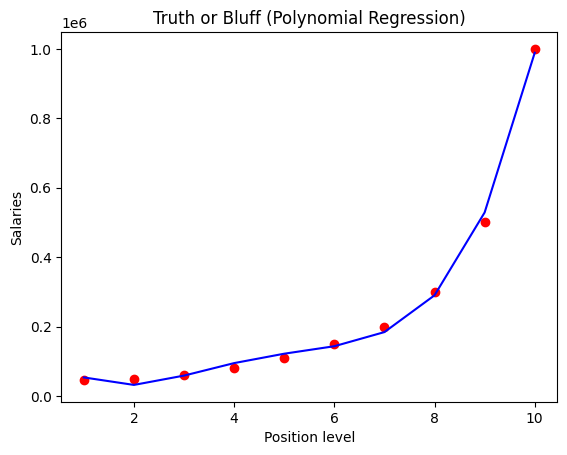

In [3]:
# VISUALIZATION 1: POLYNOMIAL REGRESSION CURVE (SMOOTHED USING GRID)
plt.scatter(X, y, color='red')
plt.plot(
    X,
    linear_1.predict(polyno.fit_transform(X)),
    color="blue",
    label="Polynomial Regression",
)
plt.title("Truth or Bluff (Polynomial Regression)")
plt.xlabel("Position level")
plt.ylabel("Salaries")
plt.show()

In [4]:
# CREATE A HIGHER RESOLUTION GRID FOR SMOOTHER CURVE VISUALIZATION
X_grid = np.arange(X.min(), X.max(), 0.1)               # CREATE VALUES FROM MIN TO MAX WITH 0.1 STEP
X_grid = X_grid.reshape((len(X_grid), 1))               # RESHAPE FOR PREDICTION

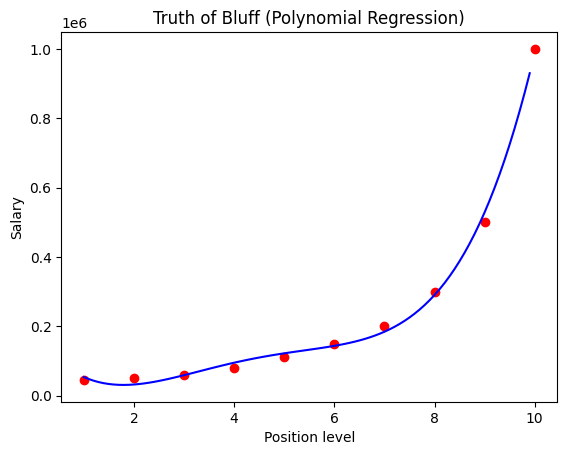

In [5]:
# VISUALIZATION 2: POLYNOMIAL REGRESSION WITH SMOOTHED CURVE
plt.scatter(X, y, color="red", label="Actual Salaries")
plt.plot(
    X_grid,
    linear_1.predict(polyno.fit_transform(X_grid)),
    color="blue",
    label="Polynomial Regression (Smoothed)",
)
plt.title("Truth of Bluff (Polynomial Regression)")
plt.xlabel("Position level")
plt.ylabel("Salary")
plt.show()

In [6]:
# PREDICT SALARY FOR POSITION LEVEL 6.5 USING LINEAR REGRESSION
linear_prediction = linear.predict(np.array(6.5).reshape(1, -1))
print(f":> LINEAR REGRESSION PREDICTION for Position Level 6.5: ${linear_prediction[0]:,.2f}")

:> LINEAR REGRESSION PREDICTION for Position Level 6.5: $330,378.79


In [7]:
# PREDICT SALARY FOR POSITION LEVEL 6.5 USING POLYNOMIAL REGRESSION (DEGREE 4)
poly_prediction = linear_1.predict(polyno.fit_transform(np.array(6.5).reshape(1, -1)))
print(f":> POLYNOMIAL REGRESSION PREDICTION (Degree 4) for Position Level 6.5: ${poly_prediction[0]:,.2f}")

:> POLYNOMIAL REGRESSION PREDICTION (Degree 4) for Position Level 6.5: $158,862.45


In [8]:
# OPTIONAL: DISPLAY MODEL COMPARISON
print("=>> MODEL COMPARISON >>")
print(f":> Linear Model R² Score: {linear.score(X, y):.4f}")
print(f":> Polynomial Model R² Score: {linear_1.score(X_train_Poly, y):.4f}")

=>> MODEL COMPARISON >>
:> Linear Model R² Score: 0.6690
:> Polynomial Model R² Score: 0.9974
